#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

#### Useful functions/classes

In [2]:
### Reads block files in input_dir up to a maximum time step (max), flattens blocks to be 1x, and
### stores them in a nested list of format all_data[spatial_location[time_step[flattened_block_index]]]: 4608x443x512
def process_data(input_dir, max, block_dim):

    all_data = []

    num_blocks = int((256/block_dim) * (96/block_dim) * (96/block_dim))
    for l in range(num_blocks):
        all_data.append([])
        for t in range(74, max):
            all_data[l].append([])
    
    for t in range(74, max):
        filename = input_dir + str(t) + "-" + str(block_dim) + ".raw"
        with open(filename, "rb") as file:
            for l in range(num_blocks):
                data = [] 
                for i in range(block_dim**3):
                    all_data[l][t-74].append(struct.unpack('<f', file.read(4))[0])
        if (t-73) % 10 == 0:
            print("Processed data from first",str(t-73),"time steps")

    return all_data
    
    
### Creates torch tensors of input/target pairs for use in the LSTM. For each target (each timestep), 
### creates an input sequence of the seq_radius steps before and after that target. Output from 
### process_data can be directly input as obs to this function.
def to_sequences(seq_radius, obs):
    x = []
    y = []
    for l in range(len(obs)): # iterate over each location
        lobs = obs[l]
        for i in range(seq_radius, len(lobs) - seq_radius): # iterate over each possible input/target pair
            window = lobs[(i - seq_radius):i] + lobs[i + 1:(i + seq_radius + 1)]
            mid_window = lobs[i]
            window = np.array(window)
            x.append(window)
            y.append(mid_window)
    x = np.array(x)
    y = np.array(y)
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class CombustionData(Dataset):
    def __init__(self, X_full, y_full):
        super().__init__()
        self.X_full = X_full
        self.y_full = y_full

    def __len__(self):
        return len(self.X_full)

    def __getitem__(self, idx):
        input = self.X_full[idx]
        output = self.y_full[idx]
        return input, output

#### Hyperparameters

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
lr = 3e-4
batch_size = 256
epochs = 100

Running on cuda


#### Data preprocessing

In [ ]:
data = process_data("volumes8/", 517, 8)
x, y = to_sequences(4, data)
print(x.shape)
print(y.shape)

# Scale the input to be between -1 and 1
xmin = x.min()
xmax = x.max()
ymin = y.min()
ymax = y.max()
xnormal = (x - xmin) / (xmax - xmin)
ynormal = (y - ymin) / (ymax - ymin)

# Initialize the dataset, split into train and validate sets, and create loaders
dataset = CombustionData(xnormal, ynormal)
train_data, val_data = random_split(dataset, [0.8, 0.2])
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=False)

Processed data from first 10 time steps
Processed data from first 20 time steps
Processed data from first 30 time steps
Processed data from first 40 time steps
Processed data from first 50 time steps
Processed data from first 60 time steps
Processed data from first 70 time steps
Processed data from first 80 time steps
Processed data from first 90 time steps
Processed data from first 100 time steps
Processed data from first 110 time steps
Processed data from first 120 time steps
Processed data from first 130 time steps
Processed data from first 140 time steps
Processed data from first 150 time steps
Processed data from first 160 time steps
Processed data from first 170 time steps
Processed data from first 180 time steps
Processed data from first 190 time steps
Processed data from first 200 time steps
Processed data from first 210 time steps
Processed data from first 220 time steps
Processed data from first 230 time steps
Processed data from first 240 time steps
Processed data from first

#### Model initialization

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                            num_layers=num_layers, batch_first=True)
        #self.dropout = nn.Dropout(0.2)
        #self.fc1 = nn.Linear(hidden_size, 1024)
        self.fc2 = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        x, _ = self.lstm(x)
        #x = self.dropout(x[:, -1, :])
        #x = self.fc1(x)
        x = self.fc2(x[:, -1, :])
        return x

model = LSTMModel(512, 1024, 3).to(device)

#### Train model

In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
#scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)

early_stop_count = 0
min_val_loss = float('inf')

train_hist = []
val_hist = []

for epoch in range(epochs):
    # Training
    model.train()
    train_losses = []
    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        train_losses.append(loss.item())
        loss.backward()
        optimizer.step()
    train_loss = np.mean(train_losses)
    train_hist.append(train_loss)

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())
    val_loss = np.mean(val_losses)
    val_hist.append(val_loss)
    #  scheduler.step(val_loss)

    if val_loss < min_val_loss:
        min_val_loss = val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1
 
    if early_stop_count >= 5:
        print("Early stopping!")
        break
    print(f"Epoch {epoch + 1}/{epochs}: Training Loss = {train_loss:.8f}, Validation Loss = {val_loss:.8f}")

Epoch 1/100: Training Loss = 0.00203608, Validation Loss = 0.00088796
Epoch 2/100: Training Loss = 0.00059251, Validation Loss = 0.00041889
Epoch 3/100: Training Loss = 0.00036107, Validation Loss = 0.00028787
Epoch 4/100: Training Loss = 0.00028806, Validation Loss = 0.00023389
Epoch 5/100: Training Loss = 0.00022679, Validation Loss = 0.00020022
Epoch 6/100: Training Loss = 0.00026286, Validation Loss = 0.00020665
Epoch 7/100: Training Loss = 0.00019082, Validation Loss = 0.00017579
Epoch 8/100: Training Loss = 0.00016863, Validation Loss = 0.00016682
Epoch 9/100: Training Loss = 0.00016224, Validation Loss = 0.00014694
Epoch 10/100: Training Loss = 0.00014325, Validation Loss = 0.00014008
Epoch 11/100: Training Loss = 0.00014841, Validation Loss = 0.00013623
Epoch 12/100: Training Loss = 0.00012834, Validation Loss = 0.00012464
Epoch 13/100: Training Loss = 0.00012163, Validation Loss = 0.00011938
Epoch 14/100: Training Loss = 0.00011573, Validation Loss = 0.00011424
Epoch 15/100: T

#### Plot loss

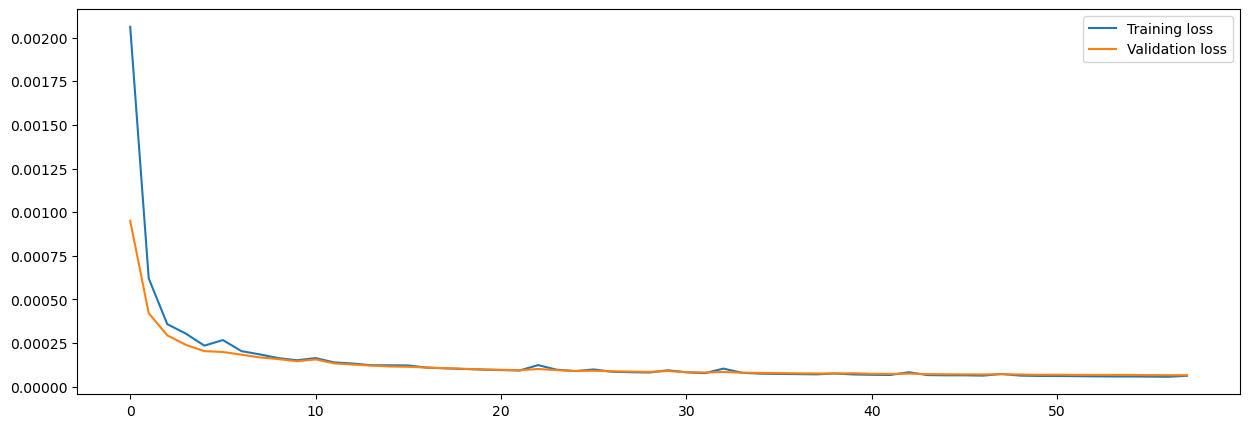

In [7]:
plt.figure(figsize=(15,5))
plt.plot(range(58), train_hist, label='Training loss')
plt.plot(range(58), val_hist, label='Validation loss')
plt.legend()